In [7]:
import sys
sys.path.append('./')
sys.path.append('../')

import numpy as np
from numpy.linalg import norm

import torch
import torchvision.datasets as datasets
import torchvision.transforms as V2
import multiprocessing

import plot as plt

from bound_propagation import BoundModelFactory, HyperRectangle, Parallel, LpNormSet

### Definition
    The norm of an image is a way to measure the "size" or "magnitude" of the image. 
    It treats the image as a vector of pixel values and calculates a measure of its length. 
    There are several ways to define the norm of an image, but the most common are:

### Types
    L1 norm: The sum of the absolute values of all pixel values.   
    L2 norm: The square root of the sum of the squares of all pixel values.   
    Infinity norm: The largest absolute pixel value in the image.

### Purpose
    The norm of an image can be used for a variety of purposes, such as:

    Measuring the similarity between two images.
    Regularizing image processing algorithms.
    Comparing the performance of different image processing algorithms.

### Applications
    The choice of norm depends on the specific application. 
    For example, the L1 norm is often used in image denoising, while the L2 norm is used in image registration. 

    https://www.physics.ntua.gr/~konstant/HetCluster/intel12.1/ipp/ipp_manual/IPPI/ippi_ch11/ch11_image_norms.htm

In [3]:
# Calculate the L2 norm of a grayscale image

def l2_norm(image):
  return np.sqrt(np.sum(np.square(image)))

# Example usage:
image = np.array([[1, 2], [3, 4]])
# In this example, the image is a 2x2 array of grayscale pixel values. 
print(image)

norm = l2_norm(image)
print(norm)  # Output: 5.477225575051661

# The L2 norm is calculated as the square root of the sum of 
# the squares of all pixel values, which is equal to 5.477.
list1D = image.ravel()
print(list1D)
sumSQ = 0
for v in list1D:
  sumSQ += v*v
normL2 = np.sqrt(sumSQ)

print('sumSQ=', sumSQ, 'norm L2=', normL2)

# # create a mini-batch as expected by the model
# listImg = torch.from_numpy(image).unsqueeze(0).unsqueeze(0)
# print(listImg.shape)
# #print(listImg[0])

[[1 2]
 [3 4]]
5.477225575051661
[1 2 3 4]
sumSQ= 30 norm L2= 5.477225575051661


# DATASETS

In [4]:
def GetMNISTDS(strDSPath, cBatch_size):
        mMean = torch.tensor([0.0])
        mSTD = torch.tensor([1.0])
        train_data = datasets.MNIST(strDSPath, train=True, 
                                download=False, transform=V2.ToTensor())
        test_data = datasets.MNIST(strDSPath, train=False, 
                                download=False, transform=V2.ToTensor())

        mDLTrain = torch.utils.data.DataLoader(train_data, 
                        batch_size=cBatch_size, 
                        shuffle=True, pin_memory=True, 
                        num_workers=min(multiprocessing.cpu_count(),4))
        mDLTest = torch.utils.data.DataLoader(test_data, 
                        #batch_size=cBatch_size,
                        batch_size=1,
                        shuffle=True, 
                        pin_memory=True, 
                        num_workers=min(multiprocessing.cpu_count(),4))

        mDLTrain.mean = mDLTest.mean = mMean
        mDLTrain.std = mDLTest.std = mSTD

        return mDLTrain, mDLTest, mMean, mSTD

def GetCIFARDL(strDSPath, nTrainSz):
        mMean = torch.tensor([0.4914, 0.4822, 0.4465])
        mSTD = torch.tensor([0.2023, 0.1994, 0.2010])
        normalize = V2.Normalize(mean = mMean, std = mSTD)
        train_data = datasets.CIFAR10(strDSPath, train=True, download=False,
                transform=V2.Compose([
                    #V2.RandomHorizontalFlip(),
                    #V2.RandomCrop(32, 4),
                    V2.ToTensor(),
                    normalize]))
        test_data = datasets.CIFAR10(strDSPath, train=False, download=False, 
                transform=V2.Compose([V2.ToTensor(), normalize]))

        mDLTrain = torch.utils.data.DataLoader(train_data, 
            batch_size=nTrainSz, 
            shuffle=True, pin_memory=True, 
            num_workers=min(multiprocessing.cpu_count(),4))
        mDLTest = torch.utils.data.DataLoader(test_data, 
            #batch_size=args.cBatch_size,
            batch_size=1,
            shuffle=True, 
            pin_memory=True, 
            num_workers=min(multiprocessing.cpu_count(),4))
        
        return mDLTrain, mDLTest, mMean, mSTD

## MNIST

In [29]:
mDLTrain, mDLTest, mMean, mSTD = GetMNISTDS('../../DATA', 100)

print('Batch Size:', len(mDLTrain))
print('Batch Size:', len(mDLTest))

cInCh = 1
cInDim = 28

print(mMean, mSTD)

Batch Size: 600
Batch Size: 10000
tensor([0.]) tensor([1.])


## CIFAR

In [8]:
mDLTrain, mDLTest, mMean, mSTD = GetCIFARDL('../../DATA', 100)

print('Batch Size:', len(mDLTrain))
print('Batch Size:', len(mDLTest))

cInCh = 3
cInDim = 32

print(mMean, mSTD)

Batch Size: 500
Batch Size: 10000
tensor([0.4914, 0.4822, 0.4465]) tensor([0.2023, 0.1994, 0.2010])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Image: torch.Size([1, 3, 32, 32]) Label: torch.Size([1])


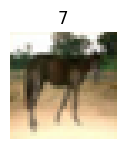

(1024,)
Norm= 2.514088


In [9]:
test_batches = enumerate(mDLTest)

# Load single batch
batch_idx, (listImg, listLabel) = next(test_batches)
print('Image:', listImg.shape, 'Label:', listLabel.shape)
# print(images[0])

strTitle = str(listLabel[0].item())

img = plt.getNormalImg(listImg[0], mSTD, mMean)
plt.ShowImg(img, strTitle, False, cInCh, cInDim, cDPI=30)

listImg1D = listImg[0][0].numpy().ravel()
print(listImg1D.shape)

print('Norm=', norm(listImg1D, np.inf))

### Get bounds using hyperrectangle

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


torch.Size([1, 3, 32, 32])
(1024,)
Norm= 3.014088
(1024,)
Norm= 2.638292


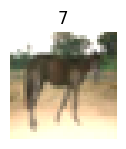

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


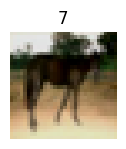

In [12]:
print(listImg.shape)

fEPS = 0.5
objHR = HyperRectangle.from_eps(listImg, fEPS)

upper1D = objHR.upper[0][0].numpy().ravel()
print(upper1D.shape)
print('Norm=', norm(upper1D, np.inf))

lower1D = objHR.lower[0][0].numpy().ravel()
print(lower1D.shape)
print('Norm=', norm(lower1D, np.inf))

img = plt.getNormalImg(objHR.upper[0], mSTD, mMean)
plt.ShowImg(img, strTitle, False, cInCh, cInDim, 30)
img = plt.getNormalImg(objHR.lower[0], mSTD, mMean)
plt.ShowImg(img, strTitle, False, cInCh, cInDim, 30)

### Noise display

Norm Noise UB= 0.010000005


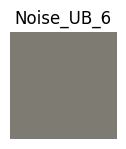

Norm Noise LB= 0.01000005


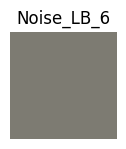

In [44]:
noise_ub = torch.sub(objHR.upper, listImg)
print('Norm Noise UB=', norm(noise_ub[0][0].numpy().ravel(), np.inf))
img = noise_ub[0]
img = plt.getNormalImg(img, mSTD, mMean)
plt.ShowImg(img, 'Noise_UB_'+ strTitle, False, cInCh, cInDim, 30)

noise_lb = torch.sub(listImg, objHR.lower)
print('Norm Noise LB=', norm(noise_lb[0][0].numpy().ravel(), np.inf))
img = plt.getNormalImg(noise_lb[0], mSTD, mMean)
plt.ShowImg(img, 'Noise_LB_'+ strTitle, False, cInCh, cInDim, 30)

### Get bounds using Linf norm

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


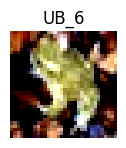

Norm= 2.224555


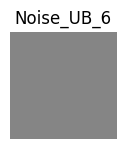

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


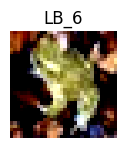

Norm= 2.3234181


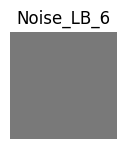

In [40]:
# Bound inputs for Linf
data_max = torch.reshape((1. - mMean) / mSTD, (1, -1, 1, 1))
#plt.ShowImg(data_max[0], 'data_max_'+ strTitle, True, cInCh, cInDim, 30)
data_min = torch.reshape((0. - mMean) / mSTD, (1, -1, 1, 1))

## Upper Bound
data_ub = torch.min(listImg + (fEPS / mSTD).view(1,-1,1,1), data_max)
plt.ShowImg(data_ub[0], 'UB_'+ strTitle, True, cInCh, cInDim, 30)
print('Norm=', norm(data_ub[0][0].numpy().ravel(), np.inf))

noise_ub = torch.sub(data_ub, listImg)
plt.ShowImg(noise_ub[0], 'Noise_UB_'+ strTitle, True, cInCh, cInDim, 30)

## Lower Bound
data_lb = torch.max(listImg - (fEPS / mSTD).view(1,-1,1,1), data_min)
plt.ShowImg(data_lb[0], 'LB_'+ strTitle, True, cInCh, cInDim, 30)
print('Norm=', norm(data_lb[0][0].numpy().ravel(), np.inf))

noise_lb = torch.sub(data_lb, listImg)
plt.ShowImg(noise_lb[0], 'Noise_LB_'+ strTitle, True, cInCh, cInDim, 30)